# PARTE 1 — IMPORTACIÓN DE LIBRERÍAS

In [ ]:
# Importación de librerías fundamentales para el análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo para visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# PARTE 2 — CARGA DEL DATASET

In [ ]:
# Carga del archivo CSV
# Nota: Utilizamos el nombre del archivo adjunto
file_path = "Encuesta-Nacional-a-las-MIPYMES-2023-Base-de-datos (10).xlsx"

# Cargamos el archivo (considerando que es un Excel)
df = pd.read_excel(file_path)

# Mostrar las primeras filas para verificar carga
print("Primeras 5 filas:")
display(df.head())

# Mostrar dimensiones
print(f"\nDimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

# Mostrar nombres de columnas
print("\nNombres de columnas:")
print(df.columns.tolist())

Primeras 5 filas:


,ID,REGIÓN,PROVINCIA,RAMA DE ACTIVIDAD,CLASIFICACIÓN MIPYMES,FORMALIDAD,GRUPO DE EDAD DEL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA,ÚLTIMO NIVEL DE ESTUDIO ALCANZADO POR EL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA,INGRESOS TOTALES,COSTOS Y GASTOS OPERACIONALES,...,"P7_12 - ¿CUÁL ES LA RAZÓN PRINCIPAL POR LA QUE NO TOMARÍA ESTE PRÉSTAMO O FINANCIAMIENTO EN ALGUNA ENTIDAD FINANCIERA COMO BANCOS MÚLTIPLES, ASOCIACIONES, BANCO DE AHORROS Y CRÉDITOS, COOPERATIVA, ETC?","P7_13 - ¿ALGUNA VEZ LE HAN RECHAZADO UN PRÉSTAMO O FINANCIAMIENTO SOLICITADO EN ALGUNA ENTIDAD FINANCIERA (BANCOS MÚLTIPLES, ASOCIACIONES, BANCOS DE AHORROS Y CRÉDITO, COOPERATIVA, ETC.) PARA LA OPERACIÓN DE LA UNIDAD ECONÓMICA (NEGOCIO O EMPRESA)?",P7_14_A - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: NO POSEE CRÉDITO,P7_14_B - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: NO TIENE GARANTÍA,P7_14_C - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: NO TIENE COMO DEMOSTRAR SUS INGRESOS,P7_14_D - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: POSEE MUCHAS DEUDAS,P7_14_E - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: NO LE DIERON RAZONES,P7_14_F - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: OTROS (ESPECIFIQUE),ESTATUS,FACTOR
0,E1,Este,La Altagracia,Construcción,MEDIANA,Formal,40-59,Técnico Superior,1.097450e+08,26945000.0,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Efectivas,7.500000
1,E2,Metropolitana,Santo Domingo,Industrias,MEDIANA,Formal,40-59,Universitaria,2.709949e+08,87723042.0,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Efectivas,17.312500
2,E3,Norte,Duarte,Comercio,MEDIANA,Formal,40-59,Universitaria,1.324010e+08,72000000.0,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Efectivas,53.785714
3,E4,Metropolitana,Distrito Nacional,"Suministro de alimentos, bebidas y alojamiento...",MEDIANA,Formal,40-59,Universitaria,1.480757e+08,98182282.0,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Efectivas,8.800000
4,E5,Metropolitana,Santo Domingo,Salud y asistencia social,PEQUEÑA,Formal,60 o más,Secundaria,4.128605e+07,1686046.0,...,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Efectivas,3.850000



Dimensiones del dataset: 13130 filas y 126 columnas

Nombres de columnas:
['ID', 'REGIÓN', 'PROVINCIA', 'RAMA DE ACTIVIDAD', 'CLASIFICACIÓN MIPYMES ', 'FORMALIDAD ', 'GRUPO DE EDAD DEL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA', 'ÚLTIMO NIVEL DE ESTUDIO ALCANZADO POR EL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA', 'INGRESOS TOTALES', 'COSTOS Y GASTOS OPERACIONALES', 'COSTO TOTAL', 'GASTO EN: COMBUSTIBLES', 'GASTO EN: SERVICIOS BÁSICOS', 'GASTO EN: SERVICIOS DE TELECOMUNICACIONES', 'GASTO EN: ALQUILERES', 'GASTO EN: PUBLICIDAD', 'DESCRIPCIÓN MEDIO PUBLICITARIO', 'GASTO EN: TRANSPORTE', 'GASTO EN: HONORARIOS PROFESIONALES', 'OTROS GASTOS N.C.P.', 'GASTOS FINANCIEROS, FISCALES Y DONACIONES', 'EMPLEO TOTAL ', 'EMPLEO HOMBRE', 'EMPLEO MUJER', 'TOTAL DE EMPLEADORES (DUEÑOS O PROPIETARIOS EN NÓMINA) ', 'TOTAL DE EMPLEADORES (DUEÑOS O PROPIETARIOS FUERA DE NÓMINA) ', 'TOTAL PERSONAL PERMANENTE', 'TOTAL PERSONAL TEMPORERO', 'TOTAL PERSONAL COMISIONISTA', 'TOTAL PERSONAL/FAMILIAR NO REMUNERADO', 'IN

# PARTE 3 — EXPLORACIÓN INICIAL

In [ ]:
# Resumen de información general
print("--- Información del Dataset ---")
df.info()

# Estadísticas básicas
print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

# Valores nulos
print("\n--- Valores Nulos ---")
print(df.isnull().sum())

# Duplicados
print(f"\nTotal de duplicados: {df.duplicated().sum()}")

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13130 entries, 0 to 13129
Columns: 126 entries, ID to FACTOR 
dtypes: float64(17), int64(10), object(99)
memory usage: 12.6+ MB

--- Estadísticas Descriptivas ---


,INGRESOS TOTALES,COSTOS Y GASTOS OPERACIONALES,COSTO TOTAL,GASTO EN: COMBUSTIBLES,GASTO EN: SERVICIOS BÁSICOS,GASTO EN: SERVICIOS DE TELECOMUNICACIONES,GASTO EN: ALQUILERES,GASTO EN: PUBLICIDAD,GASTO EN: TRANSPORTE,GASTO EN: HONORARIOS PROFESIONALES,...,TOTAL PERSONAL PERMANENTE,TOTAL PERSONAL TEMPORERO,TOTAL PERSONAL COMISIONISTA,TOTAL PERSONAL/FAMILIAR NO REMUNERADO,INGRESOS DEL PROPIETARIO FUERA DE NÓMINA,REMUNERACIONES DE LOS ASALARIADOS,SUELDOS Y SALARIOS TOTALES,CONTRIBUCIONES SOCIALES,P7_8- ¿QUÉ MEDIOS DE PAGO SE UTILIZARON DURANTE EL AÑO 2022 EN ESTE NEGOCIO O EMPRESA PARA REALIZAR SUS COMPRAS Y VENTAS?,FACTOR
count,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,1.313000e+04,...,13130.000000,13130.000000,13130.000000,13130.000000,1.313000e+04,1.313000e+04,1.313000e+04,13130.000000,0.0,13130.000000
mean,7.660416e+06,2.772882e+06,1.866766e+06,1.696701e+05,1.201028e+05,5.740121e+04,1.498203e+05,1.892006e+04,3.023761e+04,5.583232e+04,...,3.988880,0.221706,0.037091,0.055217,4.185182e+04,8.201683e+04,7.718125e+04,4835.577884,NaN,30.764052
std,2.134425e+07,9.256974e+06,7.231169e+06,1.228711e+06,8.359341e+05,4.294974e+05,8.373889e+05,3.466889e+05,4.139570e+05,7.083455e+05,...,8.481844,1.683630,0.670644,0.422442,1.274513e+05,2.473300e+05,2.313715e+05,16543.411259,NaN,29.493539
min,6.290000e+04,1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN,1.000000
25%,6.895879e+05,2.000000e+05,7.178346e+04,0.000000e+00,1.020000e+04,6.393500e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,1.000000e+04,0.000000e+00,0.000000e+00,0.000000,NaN,10.419753
50%,1.780980e+06,5.309822e+05,2.520000e+05,7.200000e+03,2.679400e+04,1.440000e+04,1.800000e+04,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000,0.000000,0.000000,0.000000,2.153000e+04,1.920000e+04,1.815950e+04,0.000000,NaN,17.430360
75%,5.667369e+06,1.615120e+06,9.360000e+05,7.000000e+04,7.302325e+04,3.263425e+04,1.200000e+05,0.000000e+00,0.000000e+00,0.000000e+00,...,4.000000,0.000000,0.000000,0.000000,4.250000e+04,7.429138e+04,7.000000e+04,3950.000000,NaN,39.523810
max,2.709949e+08,1.937592e+08,1.800100e+08,6.327872e+07,5.633772e+07,3.127342e+07,5.153922e+07,3.000000e+07,3.186783e+07,6.118712e+07,...,230.000000,65.000000,39.000000,22.000000,6.271323e+06,8.416200e+06,7.800000e+06,616200.000000,NaN,105.727532



--- Valores Nulos ---
ID                                                                                                             0
REGIÓN                                                                                                         0
PROVINCIA                                                                                                      0
RAMA DE ACTIVIDAD                                                                                              0
CLASIFICACIÓN MIPYMES                                                                                          0
                                                                                                           ...  
P7_14_D - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: POSEE MUCHAS DEUDAS     11616
P7_14_E - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOLICITADO?: NO LE DIERON RAZONES    11616
P7_14_F - ¿POR QUÉ RAZONES LE RECHAZARON EL PRÉSTAMO O FINANCIAMIENTO SOL

# PARTE 4 — IDENTIFICACIÓN DE LAS VARIABLES

In [ ]:
# PARTE 4 — IDENTIFICACIÓN DE LAS VARIABLES
# Inspeccionamos las columnas del DataFrame para localizar las variables solicitadas

print("Listado completo de columnas en el dataset:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

# Definimos las variables objetivo de acuerdo con los nombres reales encontrados en el dataset
var_ingresos = 'INGRESOS TOTALES'
var_costos = 'COSTOS Y GASTOS OPERACIONALES'
var_combustible = 'GASTO EN: COMBUSTIBLES'
var_servicios = 'GASTO EN: SERVICIOS BÁSICOS'

# Creamos un DataFrame resumen con la correspondencia exacta requerida
correspondencia = pd.DataFrame({
    'Variable solicitada': [
        'Ingresos totales',
        'Costos y gastos operacionales',
        'Gasto en combustible',
        'Gasto en servicios básicos'
    ],
    'Columna real del dataset': [
        var_ingresos,
        var_costos,
        var_combustible,
        var_servicios
    ],
    'Justificación': [
        'Corresponde directamente a los ingresos brutos anuales declarados por la empresa.',
        'Agrupa el total de costos y gastos operacionales reportados para el periodo.',
        'Mide el monto monetario anual destinado específicamente a combustibles.',
        'Registra el gasto anual en servicios esenciales como electricidad, agua, etc.'
    ]
})

print("\nTabla de Identificación de Variables:")
display(correspondencia)

Listado completo de columnas en el dataset:
0: ID
1: REGIÓN
2: PROVINCIA
3: RAMA DE ACTIVIDAD
4: CLASIFICACIÓN MIPYMES 
5: FORMALIDAD 
6: GRUPO DE EDAD DEL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA
7: ÚLTIMO NIVEL DE ESTUDIO ALCANZADO POR EL RESPONSABLE DE LA GESTIÓN DE LA EMPRESA
8: INGRESOS TOTALES
9: COSTOS Y GASTOS OPERACIONALES
10: COSTO TOTAL
11: GASTO EN: COMBUSTIBLES
12: GASTO EN: SERVICIOS BÁSICOS
13: GASTO EN: SERVICIOS DE TELECOMUNICACIONES
14: GASTO EN: ALQUILERES
15: GASTO EN: PUBLICIDAD
16: DESCRIPCIÓN MEDIO PUBLICITARIO
17: GASTO EN: TRANSPORTE
18: GASTO EN: HONORARIOS PROFESIONALES
19: OTROS GASTOS N.C.P.
20: GASTOS FINANCIEROS, FISCALES Y DONACIONES
21: EMPLEO TOTAL 
22: EMPLEO HOMBRE
23: EMPLEO MUJER
24: TOTAL DE EMPLEADORES (DUEÑOS O PROPIETARIOS EN NÓMINA) 
25: TOTAL DE EMPLEADORES (DUEÑOS O PROPIETARIOS FUERA DE NÓMINA) 
26: TOTAL PERSONAL PERMANENTE
27: TOTAL PERSONAL TEMPORERO
28: TOTAL PERSONAL COMISIONISTA
29: TOTAL PERSONAL/FAMILIAR NO REMUNERADO
30: INGRESOS DE

,Variable solicitada,Columna real del dataset,Justificación
0,Ingresos totales,INGRESOS TOTALES,Corresponde directamente a los ingresos brutos...
1,Costos y gastos operacionales,COSTOS Y GASTOS OPERACIONALES,Agrupa el total de costos y gastos operacional...
2,Gasto en combustible,GASTO EN: COMBUSTIBLES,Mide el monto monetario anual destinado especí...
3,Gasto en servicios básicos,GASTO EN: SERVICIOS BÁSICOS,Registra el gasto anual en servicios esenciale...


# PARTE 5 — LIMPIEZA Y PREPARACIÓN

In [ ]:
# Lista de variables a trabajar
cols_target = [
    'INGRESOS TOTALES',
    'COSTOS Y GASTOS OPERACIONALES',
    'GASTO EN: COMBUSTIBLES',
    'GASTO EN: SERVICIOS BÁSICOS'
]

# 1. Asegurar formato numérico
for col in cols_target:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Identificar y manejar nulos
# Decisión: Imputaremos los nulos con 0, asumiendo que si no se reportó gasto/ingreso, el valor es 0
# para permitir el cálculo estadístico sin perder datos masivamente.
df[cols_target] = df[cols_target].fillna(0)

# 3. Identificar valores negativos (imposibles en estos contextos contables)
for col in cols_target:
    count_neg = (df[col] < 0).sum()
    if count_neg > 0:
        print(f"Cambiando {count_neg} valores negativos a positivo en {col}")
        df[col] = df[col].abs()

# 4. Nota sobre outliers:
# Los outliers en MIPYMES son esperables debido a la heterogeneidad del tamaño de las empresas.
# No eliminaremos registros; se analizarán estadísticamente.

# PARTE 6 — ANÁLISIS DE VALORES NULOS Y OUTLIERS

In [ ]:
# Función para calcular límites IQR
def get_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)

# Análisis
outlier_data = []
for col in cols_target:
    q1, q3, iqr, lb, ub, n_out = get_iqr_outliers(df[col])
    outlier_data.append([col, q1, q3, iqr, lb, ub, n_out])

df_outliers = pd.DataFrame(outlier_data, columns=['Variable', 'Q1', 'Q3', 'IQR', 'Límite Inf', 'Límite Sup', 'Cant. Outliers'])
display(df_outliers)

# Interpretación: Los outliers representan empresas con operaciones de gran escala.
# Son datos reales válidos, por lo que NO deben eliminarse para no sesgar el análisis hacia las microempresas.

,Variable,Q1,Q3,IQR,Límite Inf,Límite Sup,Cant. Outliers
0,INGRESOS TOTALES,689587.870775,5.667369e+06,4.977781e+06,-6.777084e+06,1.313404e+07,1605
1,COSTOS Y GASTOS OPERACIONALES,200000.000000,1.615120e+06,1.415120e+06,-1.922680e+06,3.737800e+06,1776
2,GASTO EN: COMBUSTIBLES,0.000000,7.000000e+04,7.000000e+04,-1.050000e+05,1.750000e+05,1846
3,GASTO EN: SERVICIOS BÁSICOS,10200.000000,7.302325e+04,6.282325e+04,-8.403488e+04,1.672581e+05,1631


# PARTE 7 — CÁLCULO DE MEDIDAS ESTADÍSTICAS

In [ ]:
stats_results = []
for col in cols_target:
    data = df[col]
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]
    var = data.var()
    std = data.std()
    cv = (std / mean * 100) if mean != 0 else 0
    q3 = data.quantile(0.75)
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)

    stats_results.append([col, mean, median, mode, var, std, cv, kurt, skew, q3])

# Crear columnas de nombres para el dataframe
cols_stats = ['Variable', 'Media', 'Mediana', 'Moda', 'Varianza', 'Desv. Estándar', 'CV (%)', 'Curtosis', 'Asimetría', 'Q3']
df_stats = pd.DataFrame(stats_results, columns=cols_stats)

# PARTE 8 — TABLA RESUMEN DE RESULTADOS

In [ ]:
# Formato profesional y redondeo
pd.options.display.float_format = '{:,.2f}'.format
display(df_stats)

,Variable,Media,Mediana,Moda,Varianza,Desv. Estándar,CV (%),Curtosis,Asimetría,Q3
0,INGRESOS TOTALES,"7,660,416.23","1,780,980.47","714,586.17","455,577,206,186,209.19","21,344,254.64",278.63,60.43,6.93,"5,667,368.82"
1,COSTOS Y GASTOS OPERACIONALES,"2,772,881.69","530,982.20","500,000.00","85,691,558,603,212.03","9,256,973.51",333.84,100.06,8.64,"1,615,119.85"
2,GASTO EN: COMBUSTIBLES,"169,670.10","7,200.00",0.00,"1,509,730,955,594.07","1,228,711.10",724.18,"1,006.60",26.76,"70,000.00"
3,GASTO EN: SERVICIOS BÁSICOS,"120,102.81","26,794.00",0.00,"698,785,885,325.06","835,934.14",696.02,"2,256.13",40.93,"73,023.25"


# PARTE 9 — HISTOGRAMAS

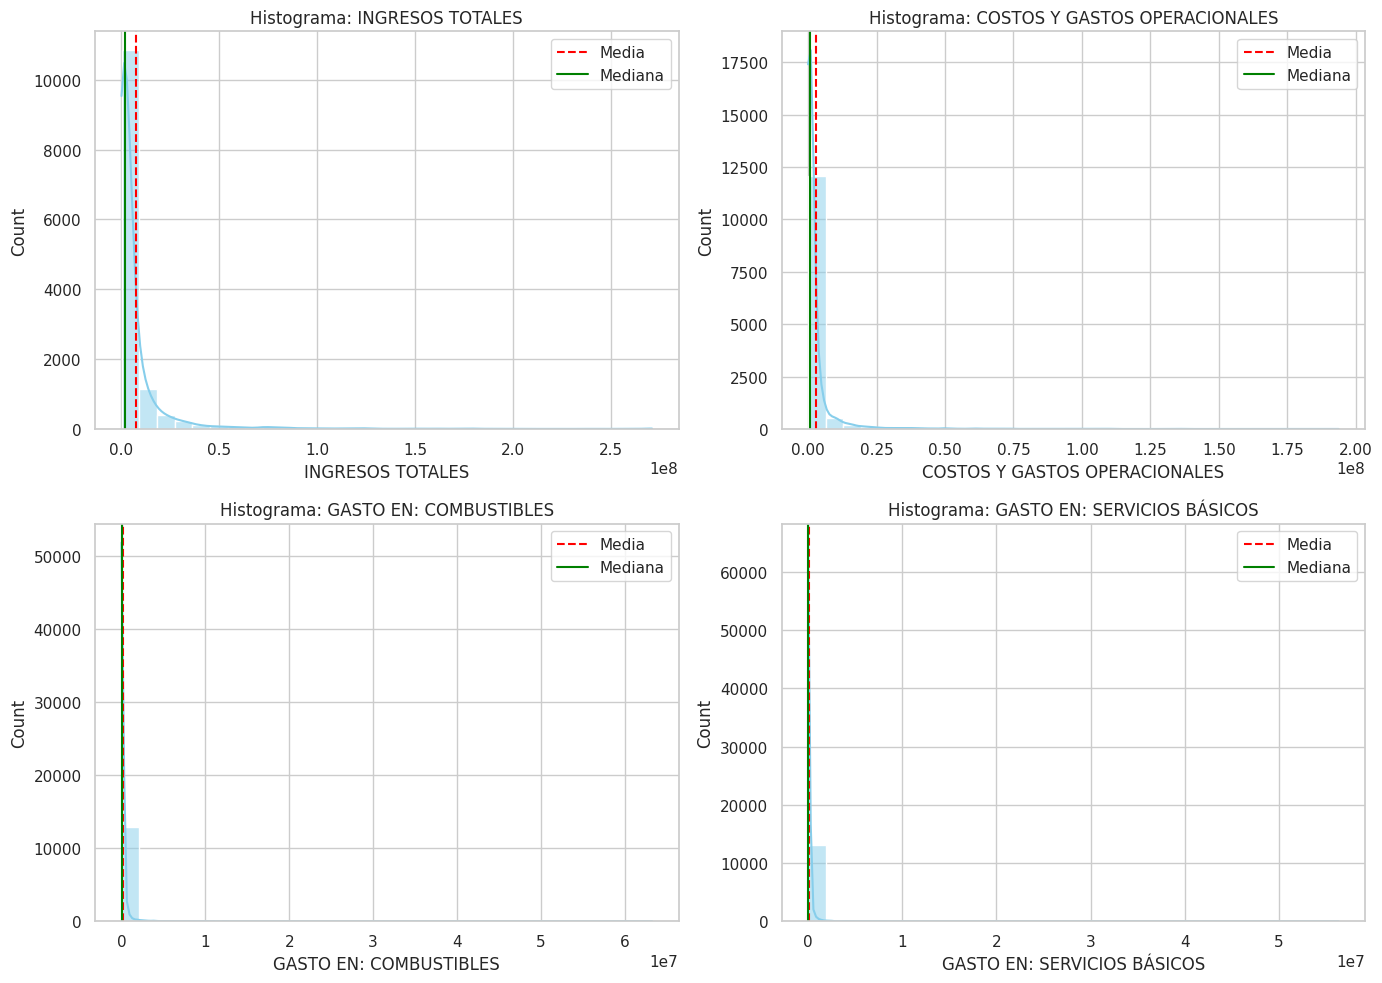

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_target):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(f'Histograma: {col}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Mediana')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Interpretación: La mayoría de estas variables presentarán un sesgo positivo extremo (asimetría),
# donde la gran mayoría de las MIPYMES tienen valores bajos y unas pocas empresas concentran los valores altos.

# PARTE 10 — BOXPLOTS

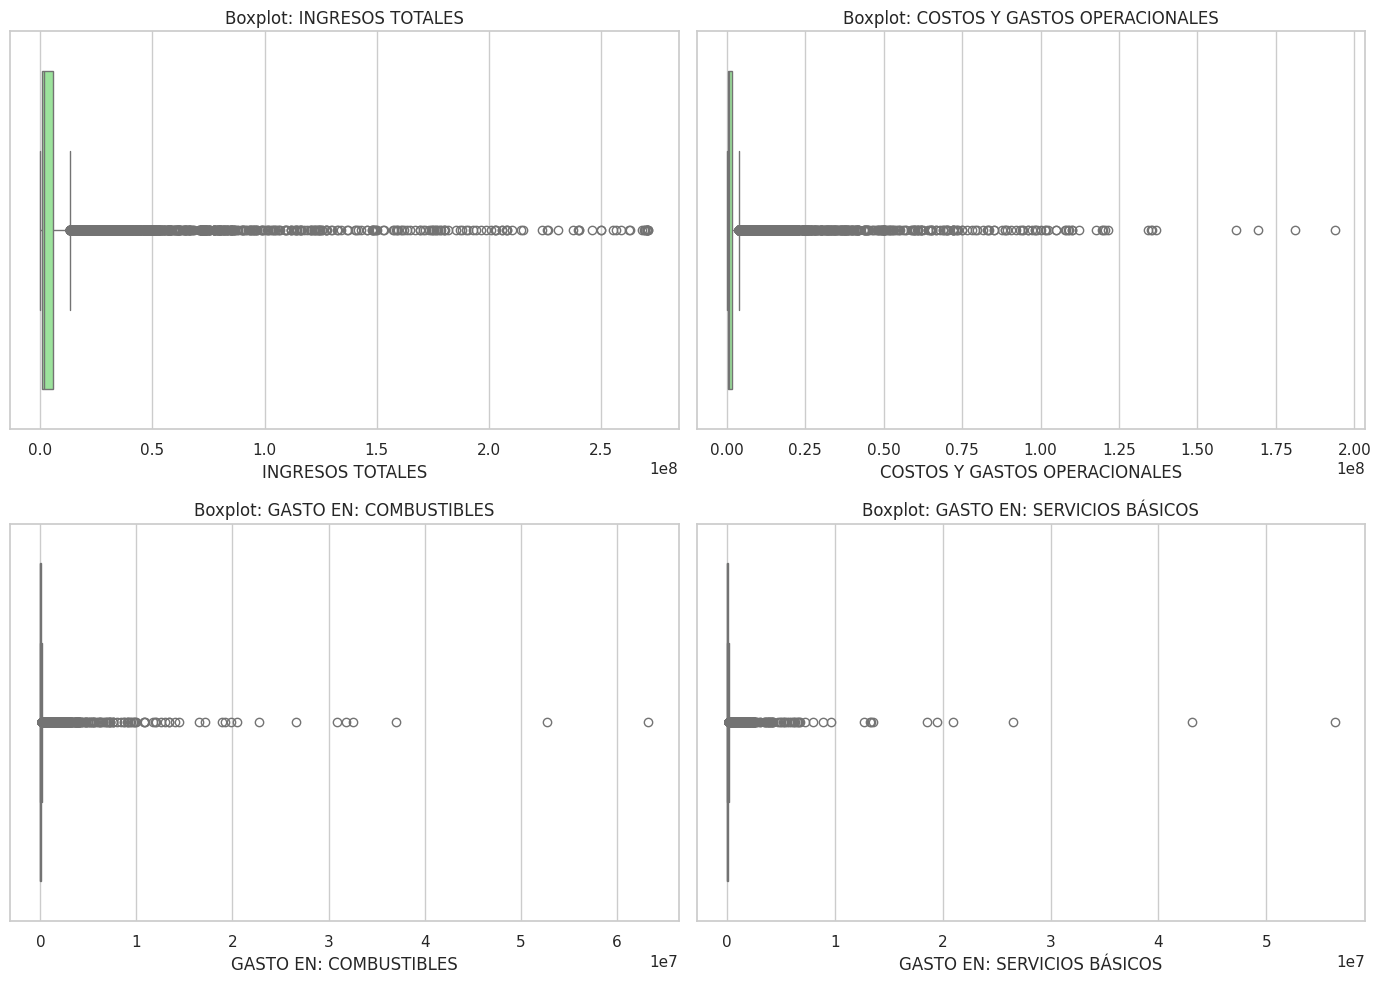

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_target):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

# Interpretación: Los boxplots confirmarán la presencia de numerosos outliers (puntos fuera de los bigotes),
# reflejando la dispersión entre microempresas y empresas medianas dentro de la misma categoría MIPYMES.

# PARTE 11 — MATRIZ DE CORRELACIÓN

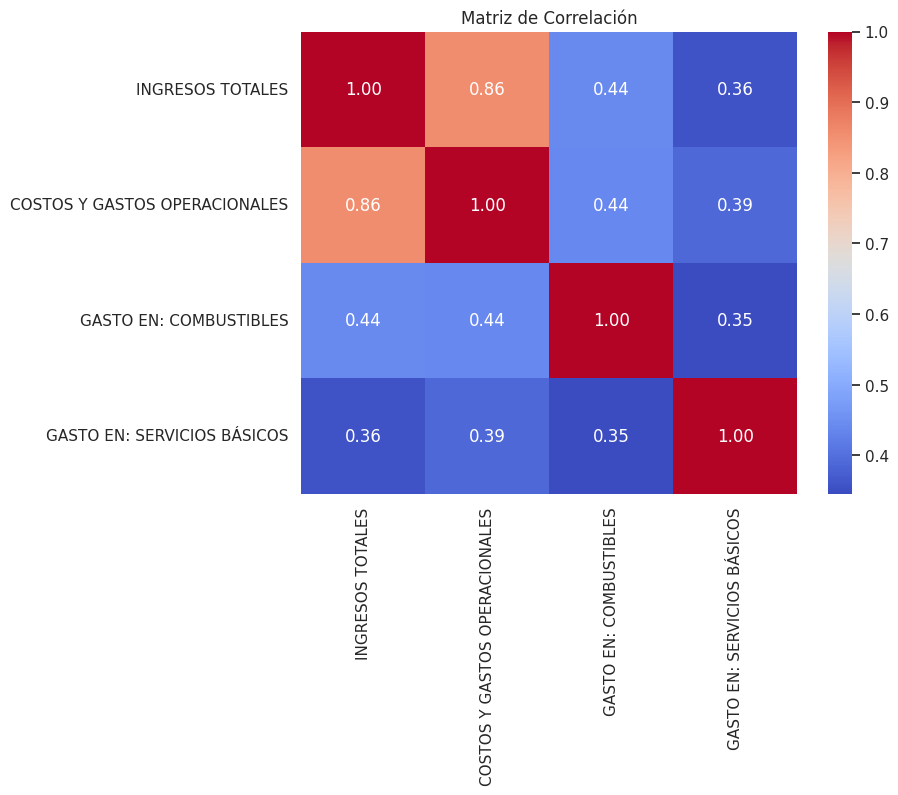

In [ ]:
# Matriz de correlación (Pearson)
corr_matrix = df[cols_target].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Nota: Correlación no implica causalidad. Se observa si existe asociación lineal positiva entre ingresos y gastos.